In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit_experiments.library.tomography import ProcessTomography, MitigatedProcessTomography
# from qiskit import QuantumCircuit
# from qiskit_ibm_runtime.fake_provider import FakeKyoto
# from qiskit_aer import AerSimulator
# from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import Chi, Choi, Kraus, SuperOp
import numpy as np
# from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
from gen_funcs import *
from post_proc_funcs import *
import pickle
import matplotlib.pyplot as plt

In [2]:
def compute_Drhp2(intmdt_map_ls, base_circ_time=90):
    ''' compute normalized non-markovianity
    inputs:
    intmdt_map_ls: list of intermediate maps
    base_circ_time: duration of the shortest circuit

    output: non-markovianity of the map built out of the list of intermediate
    maps
    '''
    gt = []
    for map in intmdt_map_ls:
        gt.append((np.linalg.norm(Choi(map), ord=1) - 1))
        # print((np.linalg.norm(Choi(map), ord=1) - 1))
    Nrhp = sum(gt)
    Drhp = 1 - np.e ** (-Nrhp)
    return Drhp


def alt_compute_Drhp(intmdt_map_ls, base_circ_time=90):
    ''' compute normalized non-markovianity
    inputs:
    intmdt_map_ls: list of intermediate maps
    base_circ_time: duration of the shortest circuit

    output: non-markovianity of the map built out of the list of intermediate
    maps
    '''
    gt = []
    for map in intmdt_map_ls:
        gt.append(np.tanh(np.linalg.norm(Choi(map), ord='nuc') - 1))
        # print((np.linalg.norm(Choi(map), ord=1) - 1))
    Nrhp = sum(gt)
    # print(Nrhp)
    try:
        Drhp = Nrhp / (len(intmdt_map_ls))
    except:
        Drhp = Nrhp
    return Drhp, gt

def compute_intermediate_maps(final_evo_list, pseudo_inv=False):
    ''' computes the last intermediate map from the list of intermediate maps
    inputs:
    phi_N: the last map of the sequence
    intermediate_list: list of intermediate maps

    output: the last intermediate map
    '''
    dim = 2 ** (final_evo_list[0].num_qubits * 2)
    # first compute the intermediate maps 
    intermediate_maps = []
    intermediate_maps.append(final_evo_list[0])
    for i in range(1, len(final_evo_list)):
        curr_applied_inv = np.identity(dim)
        for j in range(i):
            curr_applied_inv = curr_applied_inv @ np.linalg.pinv(intermediate_maps[j])
        intermediate_maps.append(final_evo_list[i] @ curr_applied_inv)

    return intermediate_maps

In [3]:
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.backend("ibm_kyoto")

In [ ]:
circ_ls_1q = gen_delay_circ_ls(1, 20, 20)
# circ_ls_2q = gen_delay_circ_ls(2, 63, 12.6)
# qubit_ls_1q = gen_qubit_ls(127, 1, repeat=False)
# qubit_ls_2q = gen_qubit_ls(126, 2, repeat=False)
batch_exp_idle_1q_mitigated = gen_batch_experiment(qc_ls=circ_ls_1q, backend=backend, num_qubits=1, mitigation=1)
# parallel_exp_idle_2q_mitigated = gen_batch_experiment(qc_ls=circ_ls_2q, backend=backend, num_qubits=2, mitigation=1)

In [6]:
parallel_1q_mitigated_result = batch_exp_idle_1q_mitigated.run(backend=backend)

In [11]:
# parallel_2q_mitigated_result = parallel_exp_idle_2q_mitigated.run(backend=backend)

In [13]:
with open('batch_1q_idle_origdata.pickle', 'wb') as handle:
    pickle.dump(parallel_1q_mitigated_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

# with open('ss2q_idle_origdata.pickle', 'wb') as handle:
#     pickle.dump(parallel_2q_mitigated_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [14]:
parallel_1q_idle_mitigated_superop_ls = extract_channel(parallel_1q_mitigated_result, vectorization=1)
with open('batch_1q_idle.pickle', 'wb') as handle:
    pickle.dump(parallel_1q_idle_mitigated_superop_ls, handle, protocol=pickle.HIGHEST_PROTOCOL)

# parallel_2q_idle_mitigated_superop_ls = extract_channel(parallel_2q_mitigated_result, vectorization=1)
# with open('ss2q_idle.pickle', 'wb') as handle:
#     pickle.dump(parallel_2q_idle_mitigated_superop_ls, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [3]:
with open(r"/Users/wangchengyu/Code/QC/550_final/proc_tomo_superop_data/batch_1q_idle.pickle", "rb") as input_file:
    parallel_1q_idle_mitigated_superop_ls = pickle.load(input_file)

In [5]:
intmdt_maps_1q_idle = compute_intermediate_maps(parallel_1q_idle_mitigated_superop_ls)
# intmdt_maps_2q_idle = compute_intmdt_maps(parallel_2q_idle_mitigated_superop_ls)
Drhp_1q_idle = compute_Drhp(intmdt_maps_1q_idle)
# Drhp_2q_idle = compute_Drhp(intmdt_maps_2q_idle)

In [18]:
# compute_Drhp2(intmdt_maps_1q_idle)

1.0

In [6]:
Drhp_1q_idle_ls = []

for i in range(0, len(parallel_1q_idle_mitigated_superop_ls)):
    curr_Drhp = alt_compute_Drhp(intmdt_maps_1q_idle[0: i])[0]
    # print(curr_Drhp)
    Drhp_1q_idle_ls.append(curr_Drhp)

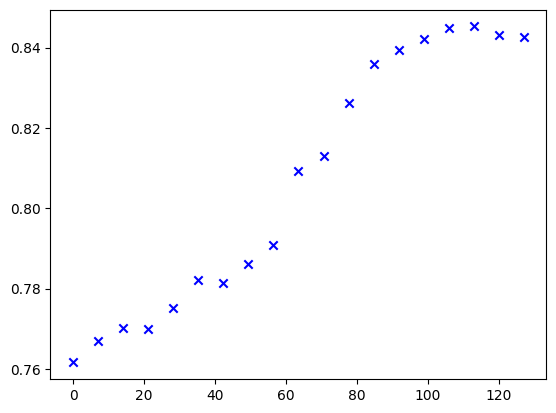

In [13]:
x = np.linspace(0, 127, 19)
plt.scatter(x, Drhp_1q_idle_ls[1:], marker='x', color='blue')
